Transition Matrix P:
 [[4.57346325e-01 1.95730342e-01 5.40467766e-02 9.21977835e-03
  9.46513139e-04]
 [1.68814325e-01 3.89090818e-01 3.15862544e-01 9.00965180e-02
  8.91562754e-03]
 [5.03440099e-02 2.42068273e-01 4.07769901e-01 2.42068273e-01
  5.03440099e-02]
 [8.91562754e-03 9.00965180e-02 3.15862544e-01 3.89090818e-01
  1.68814325e-01]
 [1.47212793e-05 3.04150819e-04 3.70276667e-03 2.69160176e-02
  1.19331402e-01]]
Simulated z_t:
 [0.         2.14242853 2.14242853 ... 1.07121426 1.07121426 0.        ]


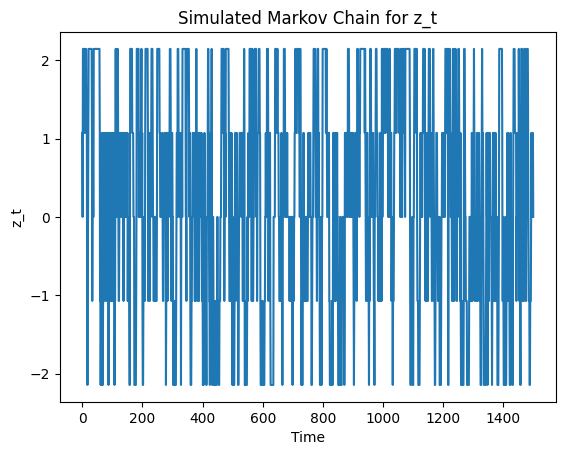

In [13]:
import numpy as np
from numpy import sqrt
from scipy.stats import norm

# Parameters 
# Ar(1) process z_t+1 = rho*z_t + (1- rho^2) epsilon_t+1 where epsilon ~ N(0,1)
rho = 0.7 
m= 3
N = 5
T = 2000 
mean_z = 0
sigma_epsilon = 1
sigma_z = (1-rho**2)

# Tauchen method 
# Creating state space for (slide 28)
Z_N = m * sqrt(sigma_z)
Z_1 = - Z_N
d = (Z_N - Z_1) / (N - 1)
z_grid = np.linspace(Z_1, Z_N, N)

# Transition matrix (slide 29)
P = np.zeros((N, N))
P_i1 = norm.cdf((z_grid[0] - rho * z_grid + d / 2) / sigma_epsilon) # First row
P_iN = 1 - norm.cdf((z_grid[-1] - rho * z_grid + d / 2) / sigma_epsilon) # Last row
P_ij = np.zeros((N-2, N)) # Middle rows 
for i in range(1, N-1):
    for j in range(N):
        P_ij[i-1, j] = norm.cdf((z_grid[j] - rho * z_grid[i] + d / 2) / sigma_epsilon) - norm.cdf((z_grid[j] - rho * z_grid[i] - d / 2) / sigma_epsilon)

P[0, :] = P_i1
P[-1, :] = P_iN
P[1:-1, :] = P_ij
print("Transition Matrix P:\n", P)

# Simulate Markov Chain 
z_sim = np.zeros(T)
for t in range(1, T):
    z_current = z_sim[t-1]
    z_index = np.argmin(np.abs(z_grid - z_current))
    probs = P[z_index, :] / np.sum(P[z_index, :])
    z_sim[t] = np.random.choice(z_grid, p=probs)
print("Simulated z_t:\n", z_sim)

# Discard first 500 observations 
z_sim = z_sim[500:]

# Plot the simulated series
import matplotlib.pyplot as plt
plt.plot(z_sim)
plt.title('Simulated Markov Chain for z_t')
plt.xlabel('Time')
plt.ylabel('z_t')
plt.show()





